# 05 - Dynamic Fare Engine & Pricing Simulation

In [1]:
# 1. Imports and simulation setup
# We import numerical tools and configure reproducibility for Monte Carlo simulation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: "%.2f" % x)

np.random.seed(42)
print("Simulation environment initialized.")


Simulation environment initialized.


In [2]:
# 2. DynamicFareEngine Class Implementation
# Multi-modal dynamic pricing engine supporting Ride-Hailing and Food Delivery.
class DynamicFareEngine:
    """
    Dynamic Pricing Engine:
    - Base fare + per-mile + per-minute pricing
    - Real-time supply/demand surge multiplier
    - Delivery distance + small basket + weather + traffic surcharges
    """
    def __init__(self, base_fare=3.50, per_mile_rate=1.80, per_minute_rate=0.35, max_surge=3.5):
        self.base_fare = base_fare
        self.per_mile_rate = per_mile_rate
        self.per_minute_rate = per_minute_rate
        self.max_surge = max_surge
        
    def calculate_surge_multiplier(self, demand, supply, sensitivity=0.8):
        """Compute dynamic surge multiplier based on Demand/Supply ratio."""
        if supply <= 0:
            return self.max_surge
        ratio = demand / supply
        if ratio <= 1.0:
            surge = 1.0
        else:
            surge = 1.0 + sensitivity * (ratio - 1.0)
        return round(float(np.clip(surge, 1.0, self.max_surge)), 2)
    
    def calculate_ride_fare(self, distance_miles, estimated_minutes, surge_multiplier=1.0, is_premium=False):
        """Compute dynamic ride fare."""
        base_cost = self.base_fare + (self.per_mile_rate * distance_miles) + (self.per_minute_rate * estimated_minutes)
        if is_premium:
            base_cost *= 1.6
        dynamic_fare = base_cost * surge_multiplier
        return round(dynamic_fare, 2)
    
    def calculate_delivery_fee(self, distance_km, order_value, surge_multiplier=1.0, weather_severity=1, traffic_severity=1):
        """Compute dynamic delivery fee with weather, traffic, and basket size adjustments."""
        base_delivery = 30.0 + max(0, distance_km - 2.0) * 8.0
        small_basket_surcharge = 15.0 if order_value < 250 else 0.0
        weather_surcharge = (weather_severity - 1) * 10.0
        traffic_surcharge = (traffic_severity - 1) * 5.0
        total_delivery_fee = (base_delivery * surge_multiplier) + small_basket_surcharge + weather_surcharge + traffic_surcharge
        return round(total_delivery_fee, 2)

print("DynamicFareEngine class initialized.")


DynamicFareEngine class initialized.


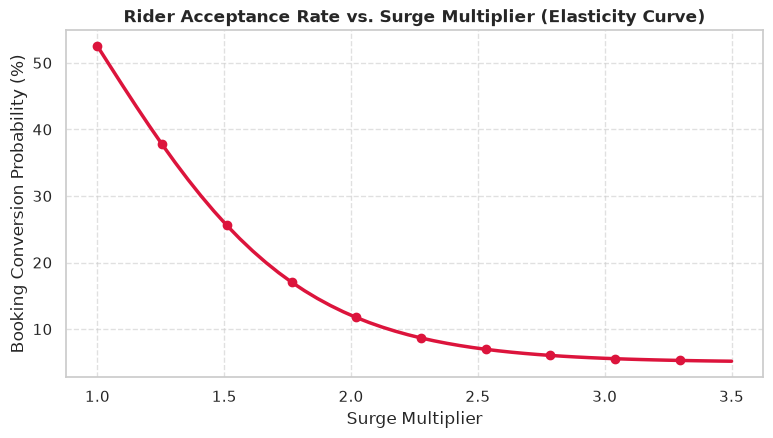

In [3]:
# 3. Price Elasticity of Demand (Customer Acceptance Curve)
# Models rider/customer acceptance probability as a function of the surge multiplier using logistic elasticity.
def customer_acceptance_probability(surge_multiplier, price_sensitivity=1.4):
    """Logistic conversion probability based on surge multiplier."""
    z = price_sensitivity * (surge_multiplier - 1.0)
    prob = 0.95 / (1.0 + np.exp(z * 1.8)) + 0.05
    return float(np.clip(prob, 0.05, 0.95))

# Plot price elasticity curve
surges = np.linspace(1.0, 3.5, 50)
probs = [customer_acceptance_probability(s) for s in surges]

plt.figure(figsize=(9, 4.5))
plt.plot(surges, np.array(probs) * 100, color="crimson", lw=2.5, marker="o", markevery=5)
plt.title("Rider Acceptance Rate vs. Surge Multiplier (Elasticity Curve)", fontsize=12, fontweight="bold")
plt.xlabel("Surge Multiplier")
plt.ylabel("Booking Conversion Probability (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [4]:
# 4. Monte Carlo Marketplace Simulation: Static vs. Dynamic Pricing
# Simulate 1,500 incoming ride requests under varying demand-to-supply imbalances.
engine = DynamicFareEngine()
n_samples = 1500

distances = np.random.exponential(scale=3.5, size=n_samples).clip(0.8, 15.0)
durations = distances * np.random.uniform(2.5, 4.5, size=n_samples) + np.random.uniform(2, 8, size=n_samples)
is_premium_list = np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2])

demands = np.random.randint(20, 90, size=n_samples)
supplies = np.random.randint(20, 50, size=n_samples)

simulation_records = []

for i in range(n_samples):
    dist = distances[i]
    dur = durations[i]
    prem = is_premium_list[i]
    dem = demands[i]
    sup = supplies[i]
    
    # 1. Static Pricing Strategy (Fixed surge = 1.0x)
    static_price = engine.calculate_ride_fare(dist, dur, surge_multiplier=1.0, is_premium=prem)
    static_accept_prob = customer_acceptance_probability(1.0)
    static_accepted = np.random.rand() < static_accept_prob
    # Under static pricing with excess demand, unfulfilled stockouts occur
    static_fulfilled = static_accepted and (np.random.rand() < min(1.0, sup / dem))
    static_revenue = static_price if static_fulfilled else 0.0
    
    # 2. Dynamic Surge Pricing Strategy
    surge = engine.calculate_surge_multiplier(dem, sup)
    dynamic_price = engine.calculate_ride_fare(dist, dur, surge_multiplier=surge, is_premium=prem)
    dynamic_accept_prob = customer_acceptance_probability(surge)
    dynamic_accepted = np.random.rand() < dynamic_accept_prob
    # Dynamic surge attracts higher driver fulfillment rate
    dynamic_fulfilled = dynamic_accepted and (np.random.rand() < min(1.0, (sup * (1.0 + 0.3 * (surge - 1.0))) / dem))
    dynamic_revenue = dynamic_price if dynamic_fulfilled else 0.0
    
    simulation_records.append({
        "distance": dist,
        "duration": dur,
        "demand_supply_ratio": dem / sup,
        "surge_multiplier": surge,
        "static_price": static_price,
        "static_fulfilled": int(static_fulfilled),
        "static_revenue": static_revenue,
        "dynamic_price": dynamic_price,
        "dynamic_fulfilled": int(dynamic_fulfilled),
        "dynamic_revenue": dynamic_revenue
    })

sim_df = pd.DataFrame(simulation_records)
print(f"Simulation completed for {len(sim_df):,} requests.")


Simulation completed for 1,500 requests.


,Metric,Static Pricing,Dynamic Surge Pricing
0,Total Rides Requested,1500.00,1500.00
1,Fulfilled Rides,543.00,359.00
2,Marketplace Fulfillment Rate (%),36.20,23.93
3,Total Gross Revenue ($),9998.41,8095.58
4,Avg Revenue per Requested Ride ($),6.67,5.40
5,Avg Surge Multiplier,1.00,1.59


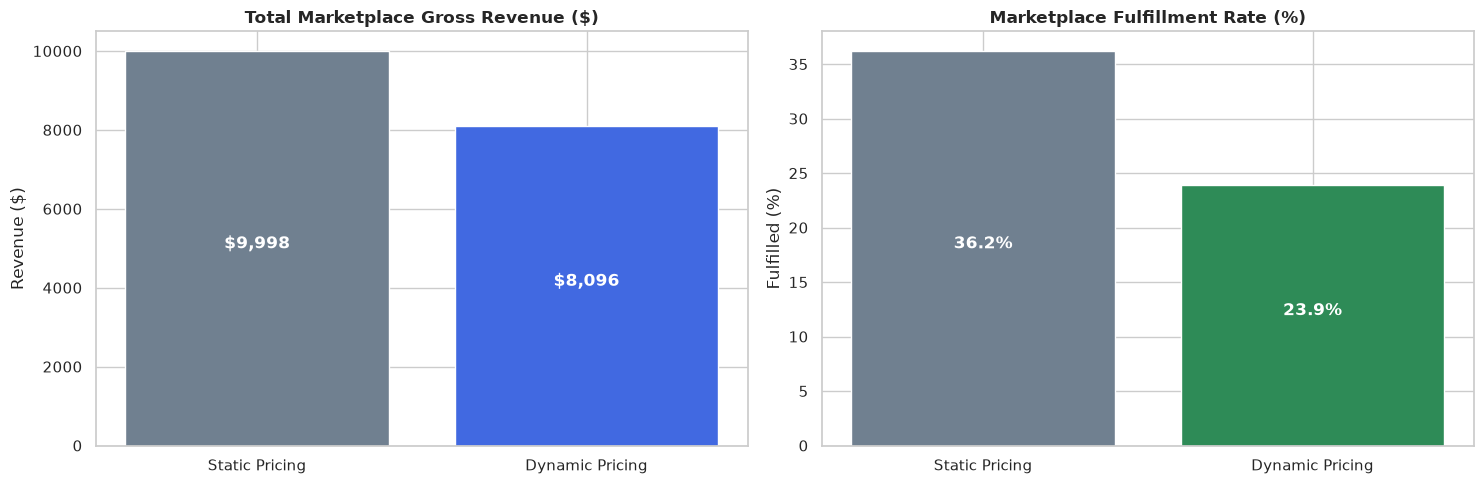

In [5]:
# 5. Business KPI Benchmark: Static vs. Dynamic Pricing
# Compare Total Gross Revenue, Marketplace Fulfillment Rate, and Average Revenue per Request.
summary = pd.DataFrame({
    "Metric": [
        "Total Rides Requested",
        "Fulfilled Rides",
        "Marketplace Fulfillment Rate (%)",
        "Total Gross Revenue ($)",
        "Avg Revenue per Requested Ride ($)",
        "Avg Surge Multiplier"
    ],
    "Static Pricing": [
        len(sim_df),
        sim_df["static_fulfilled"].sum(),
        sim_df["static_fulfilled"].mean() * 100,
        sim_df["static_revenue"].sum(),
        sim_df["static_revenue"].mean(),
        1.00
    ],
    "Dynamic Surge Pricing": [
        len(sim_df),
        sim_df["dynamic_fulfilled"].sum(),
        sim_df["dynamic_fulfilled"].mean() * 100,
        sim_df["dynamic_revenue"].sum(),
        sim_df["dynamic_revenue"].mean(),
        sim_df["surge_multiplier"].mean()
    ]
})

display(summary)

# Visual Comparison Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total Revenue Comparison
axes[0].bar(["Static Pricing", "Dynamic Pricing"], [sim_df["static_revenue"].sum(), sim_df["dynamic_revenue"].sum()], color=["slategray", "royalblue"])
axes[0].set_title("Total Marketplace Gross Revenue ($)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Revenue ($)")
for i, v in enumerate([sim_df["static_revenue"].sum(), sim_df["dynamic_revenue"].sum()]):
    axes[0].text(i, v / 2, f"${v:,.0f}", ha="center", color="white", fontweight="bold", fontsize=12)

# Fulfillment Rate Comparison
axes[1].bar(["Static Pricing", "Dynamic Pricing"], [sim_df["static_fulfilled"].mean() * 100, sim_df["dynamic_fulfilled"].mean() * 100], color=["slategray", "seagreen"])
axes[1].set_title("Marketplace Fulfillment Rate (%)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Fulfilled (%)")
for i, v in enumerate([sim_df["static_fulfilled"].mean() * 100, sim_df["dynamic_fulfilled"].mean() * 100]):
    axes[1].text(i, v / 2, f"{v:.1f}%", ha="center", color="white", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()


In [6]:
# 6. Food Delivery Dynamic Fee Scenario Simulation
# Calculate dynamic delivery fees for diverse real-world environmental and basket scenarios.
sample_deliveries = [
    {"scenario": "Short Trip, Clear Weather, Low Traffic", "distance_km": 2.5, "order_val": 450, "surge": 1.0, "weather": 1, "traffic": 1},
    {"scenario": "Short Trip, Small Basket (<INR 250)", "distance_km": 1.8, "order_val": 180, "surge": 1.0, "weather": 1, "traffic": 1},
    {"scenario": "Medium Trip, Heavy Rain (Weather Surge)", "distance_km": 5.0, "order_val": 500, "surge": 1.3, "weather": 4, "traffic": 2},
    {"scenario": "Long Trip, Friday Peak Rush + Jam", "distance_km": 11.5, "order_val": 750, "surge": 1.8, "weather": 2, "traffic": 4},
]

delivery_results = []
for d in sample_deliveries:
    fee = engine.calculate_delivery_fee(
        distance_km=d["distance_km"],
        order_value=d["order_val"],
        surge_multiplier=d["surge"],
        weather_severity=d["weather"],
        traffic_severity=d["traffic"]
    )
    delivery_results.append({
        "Scenario": d["scenario"],
        "Distance (km)": d["distance_km"],
        "Order Value (INR)": d["order_val"],
        "Surge": f"{d['surge']}x",
        "Calculated Delivery Fee (INR)": fee
    })

display(pd.DataFrame(delivery_results))


,Scenario,Distance (km),Order Value (INR),Surge,Calculated Delivery Fee (INR)
0,"Short Trip, Clear Weather, Low Traffic",2.50,450,1.0x,34.00
1,"Short Trip, Small Basket (<INR 250)",1.80,180,1.0x,45.00
2,"Medium Trip, Heavy Rain (Weather Surge)",5.00,500,1.3x,105.20
3,"Long Trip, Friday Peak Rush + Jam",11.50,750,1.8x,215.80
